# 17 · ROS 2: communication for behaviors

## Learning objectives

- Explain nodes, topics, services, actions, and executors before using them.
- Exchange a message and a request between two nodes.
- Own ROS resources explicitly in a rerunnable notebook.

**Environment:** ROS 2 Jazzy, sourced workspace, and the ROS notebook kernel from the README. Every ROS example owns and closes its context; run cells in order. Do not call `rclpy.spin` on nodes already managed by `RosSession`.

## Intuition

So far, a function call reached our whole simulated world. A robot often has separate
programs for sensors, motion, and decisions. **ROS 2** helps those programs communicate.
A **ROS node** is a participant with communication resources; it is not a BT node. One ROS
node can own an entire behavior tree.

| Concept | Purpose | BT connection |
|---|---|---|
| Topic | A stream of typed messages from publishers to subscribers | Update observations |
| Service | One typed request and one response | Ask for a short operation |
| Action | A goal, feedback, result, and cancellation protocol | Represent long-running work |
| Executor | Dispatch callbacks when messages, timers, or futures are ready | Let communication progress between ticks |

Topics decouple producers from consumers. Services fit short operations with a definite
reply. Actions fit work such as navigation that takes time and may need cancellation.
A **future** is a handle for a result that will become available later. Polling whether it is
done is cheap; waiting synchronously inside a tick can stall the whole controller.

A single-threaded executor runs one callback at a time. A multithreaded executor can run
eligible callbacks concurrently, subject to callback groups. A reentrant callback group
allows overlap; a mutually exclusive group prevents it. More threads do not make shared
mutable data automatically safe.

## Minimal working example
ROS must be initialized before creating nodes. In a notebook we use a fresh `Context`
(an independent ROS initialization scope) per demonstration. `RosSession` owns that context,
one executor, its background spin thread, and all added nodes. Leaving `with` stops callbacks,
joins the thread, destroys nodes, and shuts down the context, including on exceptions.

In [1]:
from behavior_trees_tutorial.ros_nodes.session import RosSession
from uuid import uuid4
from std_msgs.msg import String
from std_srvs.srv import Trigger

with RosSession() as ros:
    namespace = "/lesson17_" + uuid4().hex
    sensor = ros.node("sensor", namespace=namespace)
    controller = ros.node("controller", namespace=namespace)
    received = []
    subscription = controller.create_subscription(String, "observation", lambda msg: received.append(msg.data), 10)
    publisher = sensor.create_publisher(String, "observation", 10)
    # Discovery is asynchronous. Wait for a matched subscriber before publishing once.
    ros.wait(lambda: publisher.get_subscription_count() > 0)
    publisher.publish(String(data="door open"))
    ros.wait(lambda: bool(received))
    assert received[-1] == "door open"
    print("Topic:", received[-1])

Topic: door open


## Step-by-step implementation
A service callback fills a response. `Trigger` is an existing interface with an empty
request and a success/message response, suitable for a tiny “check readiness” operation.
Here both nodes live in one process for easy inspection; DDS communication also works when
they live in separate processes. The queue depth 10 is a QoS setting, not a guarantee that
an unsent or unmatched message will be retained.

In [2]:
with RosSession() as ros:
    namespace = "/service_" + uuid4().hex
    device = ros.node("device", namespace=namespace)
    controller = ros.node("controller", namespace=namespace)

    def ready(request, response):
        response.success, response.message = True, "ready"
        return response

    service = device.create_service(Trigger, "ready", ready)
    client = controller.create_client(Trigger, "ready")
    ros.wait(client.service_is_ready)
    future = client.call_async(Trigger.Request())
    ros.wait(future.done)
    assert future.result().success
    print("Service:", future.result().message)

Service: ready


An action uses a richer protocol: send a goal, wait for acceptance, observe feedback,
then inspect its terminal result. Accepted does not mean successful. Cancellation is a request
that must be acknowledged, not an immediate physical stop. Lesson 19 runs the complete
protocol against a simulated server. Before then, here is how observations enter a BT.

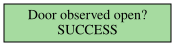

In [3]:
import py_trees as pt
from behavior_trees_tutorial.behaviors.common import Function, CountTicks, Status
from behavior_trees_tutorial.visualization import diagram, trace, playground
from IPython.display import display
observation = {"door_open": received[-1] == "door open"}
root = Function("Door observed open?", lambda: Status.SUCCESS if observation["door_open"] else Status.FAILURE)
root.tick_once()
display(diagram(root))

## Interactive demonstration
This intentionally uses local data after ROS cleanup. It keeps widget callbacks from
retaining live nodes indefinitely. To repeat network communication, rerun either `with`
cell; no kernel restart is necessary.

In [4]:
import ipywidgets as widgets

@widgets.interact(door_open=True)
def observation_to_decision(door_open=True):
    observation["door_open"] = door_open
    root.tick_once()
    display(diagram(root))

interactive(children=(Checkbox(value=True, description='door_open'), Output()), _dom_classes=('widget-interact…

## Key observations

An executor progresses communication; a tick progresses decisions. Never spin a node from two executors, or call spin_until_future_complete on a node already owned by RosSession.

## Exercises

1. Publish a second observation.
2. Make the service report not ready.
3. Choose a topic, service, or action for a camera frame, reset request, and navigation goal.

Hints and worked solutions: `exercises/README.md` and `solutions/README.md` (lesson 17).

## Summary

ROS supplies communication and scheduling. The BT decision rules remain unchanged.